# Eksperimen 6: Visualisasi Biomechanical Attention — Fase Serius

Notebook ini menggabungkan **bobot atensi mentah dari model** (sigmoid BSP) dengan
**Exercise-Specific Spatial Prior Mask** (aturan biomekanika murni) untuk menghasilkan
visualisasi attention yang bermakna dan dapat diinterpretasi secara ilmiah.

**Formula Final Attention:**

$$\text{final\_attention}_i = \text{raw\_attention}_i \times \text{prior\_mask}_i$$

Lalu di-**Min-Max Normalize** agar kontras warna penuh.

**Struktur Notebook:**

| Cell | Isi |
|---|---|
| **1. Setup & Load Model** | Import library, muat `best_model.pth`, ekstrak `raw_attention` |
| **2. Fungsi Visualisasi** | `render_biomechanical_attention()` — glow + warna adaptif |
| **3. Eksekusi SQUAT** | Prior mask: Pinggul (23,24) & Lutut (25,26) = 1.0 |
| **4. Eksekusi DEADLIFT** | Prior mask: Bahu (11,12), Pinggul (23,24) & Lutut (25,26) = 1.0 |
| **5. Eksekusi BENCH PRESS** | Prior mask: Bahu (11,12), Siku (13,14) & Pergelangan Tangan (15,16) = 1.0 |

**Skema warna (berdasarkan `final_attention_normalized`):**

| Nilai Ternormalisasi | Warna | Radius | Teks |
|---|---|---|---|
| **> 0.4** (kritis) | 🔴 Merah Terang + Glow | Besar (16px) | nilai raw asli (e.g. `0.76`) — CYAN |
| **≤ 0.4** (non-kritis) | ⚫ Abu-abu Redup | Kecil (5px) | nilai raw asli (e.g. `0.68`) — Cyan redup |


## 1. Setup & Load Model


In [18]:

# ============================================================
# 1. Setup & Load Model
#    - Import semua library
#    - Muat best_model.pth
#    - Ekstrak raw_attention = torch.sigmoid(biomechanical_spatial_prior)
# ============================================================
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import sys

import torch

# ── Setup sys.path ─────────────────────────────────────────────────────────────
ROOT_DIR = Path("..").resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.models.model_3dcnn import AttentiveSkel3D

# ── Inisialisasi MediaPipe ─────────────────────────────────────────────────────
mp_pose = mp.solutions.pose

# ── Muat Model ─────────────────────────────────────────────────────────────────
MODEL_PATH = Path("../models/saved_models/best_model.pth")
model = AttentiveSkel3D(num_classes=2)

print(f"Memuat checkpoint dari : {MODEL_PATH}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"File model tidak ditemukan: {MODEL_PATH}")

checkpoint = torch.load(str(MODEL_PATH), map_location="cpu")
if isinstance(checkpoint, dict):
    if "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
        print("  Format checkpoint   : {'model_state_dict': ...}")
    elif "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
        print("  Format checkpoint   : {'state_dict': ...}")
    else:
        model.load_state_dict(checkpoint)
        print("  Format checkpoint   : state_dict langsung (dict)")
else:
    model.load_state_dict(checkpoint)
    print("  Format checkpoint   : state_dict langsung")

model.eval()
print("  Status model        : eval() — siap untuk inferensi\n")

# ── Ekstrak raw_attention = sigmoid(biomechanical_spatial_prior) ───────────────
with torch.no_grad():
    bsp_raw       = model.biomechanical_spatial_prior   # shape: (1, 1, 1, 33, 1)
    bsp_sigmoid   = torch.sigmoid(bsp_raw)
    raw_attention = bsp_sigmoid.squeeze().cpu().numpy().astype(np.float32)  # shape: (33,)

print("raw_attention (sigmoid BSP) berhasil diekstrak:")
print(f"  Shape : {raw_attention.shape}  (33 landmark BlazePose)")
print(f"  Min   : {raw_attention.min():.4f}")
print(f"  Max   : {raw_attention.max():.4f}")
print(f"  Mean  : {raw_attention.mean():.4f}")
print(f"  Std   : {raw_attention.std():.4f}")
print()
print(f"  OpenCV    : {cv2.__version__}")
print(f"  MediaPipe : {mp.__version__}")
print(f"  PyTorch   : {torch.__version__}")
print(f"  Root dir  : {ROOT_DIR}")


Memuat checkpoint dari : ..\models\saved_models\best_model.pth
  Format checkpoint   : {'model_state_dict': ...}
  Status model        : eval() — siap untuk inferensi

raw_attention (sigmoid BSP) berhasil diekstrak:
  Shape : (33,)  (33 landmark BlazePose)
  Min   : 0.6802
  Max   : 0.7639
  Mean  : 0.7265
  Std   : 0.0234

  OpenCV    : 4.13.0
  MediaPipe : 0.10.14
  PyTorch   : 2.5.1
  Root dir  : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19852\3734266089.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(str(MODEL_PATH), map_locati

## 2. Fungsi Visualisasi Utama: `render_biomechanical_attention()`


In [19]:

def render_biomechanical_attention(
    video_path: str,
    output_path: str,
    raw_attention: np.ndarray,       # (33,) sigmoid BSP dari model
    exercise_prior_mask: np.ndarray, # (33,) prior biomekanik per latihan
) -> str | None:
    """
    Render video dengan visualisasi Biomechanical Attention.

    Logika utama:
      1. final_attention   = raw_attention × exercise_prior_mask
      2. normalized        = Min-Max Normalization(final_attention)  → [0.0, 1.0]
      3. Pewarnaan per landmark (berdasarkan normalized):
           normalized > 0.4  →  MERAH TERANG + Glow (radius besar 16px)
           normalized ≤ 0.4  →  ABU-ABU REDUP          (radius kecil 5px)
      4. Teks nilai raw_attention ASLI (2 desimal) di sebelah tiap sendi — warna CYAN.
      5. Overlay HUD: judul, formula, Top-5 atensi tertinggi, nomor frame.

    Args:
        video_path          : Path video input .mp4
        output_path         : Path video output .mp4
        raw_attention       : Array float32 (33,) — nilai sigmoid BSP dari model
        exercise_prior_mask : Array float32 (33,) — 1.0 untuk sendi kritis, 0.1 untuk lainnya

    Returns:
        str | None: Path gambar best-frame (.jpg), atau None jika tidak ada pose terdeteksi
    """
    video_path  = Path(video_path)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    raw_w  = np.array(raw_attention,       dtype=np.float32)  # (33,)
    mask_w = np.array(exercise_prior_mask, dtype=np.float32)  # (33,)

    # ── 1. Hitung final_attention ──────────────────────────────────────────────
    final_w = raw_w * mask_w

    # ── 2. Min-Max Normalization ───────────────────────────────────────────────
    _min   = final_w.min()
    _max   = final_w.max()
    _eps   = 1e-8
    norm_w = (final_w - _min) / (_max - _min + _eps)

    print(f"  raw_attention (sigmoid BSP) : min={raw_w.min():.4f}, max={raw_w.max():.4f}")
    print(f"  final_attention (×mask)     : min={final_w.min():.4f}, max={final_w.max():.4f}")
    print(f"  normalized (Min-Max)        : min={norm_w.min():.4f}, max={norm_w.max():.4f}")

    # Konstanta visual
    THRESHOLD    = 0.4
    RADIUS_BIG   = 16
    RADIUS_SMALL = 5
    COLOR_RED    = (0, 0, 255)      # BGR: Merah terang
    COLOR_GRAY   = (100, 100, 100)  # BGR: Abu-abu redup

    # Top-5 berdasarkan final_attention — ditampilkan dengan nilai raw asli
    top5_idx = np.argsort(final_w)[::-1][:5]
    top5_str = "  ".join(f"#{int(i)}:{raw_w[i]:.2f}" for i in top5_idx)

    # ── Buka video ─────────────────────────────────────────────────────────────
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Tidak dapat membuka video: {video_path}")

    fps          = cap.get(cv2.CAP_PROP_FPS) or 30.0
    width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"  Video: {video_path.name}  |  {width}×{height}px  |  {fps:.1f} FPS  |  {total_frames} frame")

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    best_frame = None
    best_score = -1.0
    frame_idx  = 0

    with mp_pose.Pose(
        model_complexity=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as pose_detector:

        while cap.isOpened():
            ret, frame_bgr = cap.read()
            if not ret:
                break

            frame_idx += 1
            h, w = frame_bgr.shape[:2]

            # Gelapkan background (40% kecerahan asli)
            frame_dark = (frame_bgr.astype(np.float32) * 0.40).astype(np.uint8)

            # Deteksi pose
            frame_rgb    = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            pose_results = pose_detector.process(frame_rgb)

            if pose_results.pose_landmarks is None:
                writer.write(frame_dark)
                continue

            landmarks = pose_results.pose_landmarks.landmark
            frame_out = frame_dark.copy()

            # ── Pass 1: Efek Glow (sendi kritis norm > threshold) ──────────────
            glow_layer = np.zeros_like(frame_out)
            for idx in range(min(33, len(landmarks))):
                lm = landmarks[idx]
                if lm.visibility < 0.3 or norm_w[idx] <= THRESHOLD:
                    continue
                px = int(lm.x * w)
                py = int(lm.y * h)
                cv2.circle(glow_layer, (px, py), RADIUS_BIG + 18, COLOR_RED, -1)

            glow_blurred = cv2.GaussianBlur(glow_layer, (51, 51), 20)
            frame_out    = cv2.addWeighted(frame_out, 1.0, glow_blurred, 0.60, 0)

            # ── Pass 2: Garis koneksi skeleton ─────────────────────────────────
            for connection in mp_pose.POSE_CONNECTIONS:
                s_idx, e_idx = connection
                if s_idx >= len(landmarks) or e_idx >= len(landmarks):
                    continue
                lm_s = landmarks[s_idx]
                lm_e = landmarks[e_idx]
                if lm_s.visibility < 0.3 or lm_e.visibility < 0.3:
                    continue
                x1 = int(lm_s.x * w);  y1 = int(lm_s.y * h)
                x2 = int(lm_e.x * w);  y2 = int(lm_e.y * h)
                avg_norm = (norm_w[s_idx] + norm_w[e_idx]) / 2.0
                if avg_norm > THRESHOLD:
                    cv2.line(frame_out, (x1, y1), (x2, y2), (0, 0, 200), 3, cv2.LINE_AA)
                else:
                    cv2.line(frame_out, (x1, y1), (x2, y2), (70, 70, 70), 1, cv2.LINE_AA)

            # ── Pass 3: Titik sendi + teks nilai raw ───────────────────────────
            for idx in range(min(33, len(landmarks))):
                lm = landmarks[idx]
                if lm.visibility < 0.3:
                    continue
                px = int(lm.x * w)
                py = int(lm.y * h)

                if norm_w[idx] > THRESHOLD:
                    # MERAH TERANG — sendi kritis
                    cv2.circle(frame_out, (px, py), RADIUS_BIG, COLOR_RED, -1, cv2.LINE_AA)
                    cv2.circle(frame_out, (px, py), RADIUS_BIG, (255, 255, 255), 2, cv2.LINE_AA)
                    cv2.circle(frame_out, (px, py), 3, (255, 255, 255), -1, cv2.LINE_AA)
                    # Indeks + nilai raw asli — warna CYAN terang
                    cv2.putText(
                        frame_out, f"{idx}: {raw_w[idx]:.2f}",
                        (px + RADIUS_BIG + 4, py - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55,
                        (0, 255, 255), 2, cv2.LINE_AA,
                    )
                else:
                    # ABU-ABU REDUP — sendi non-kritis
                    cv2.circle(frame_out, (px, py), RADIUS_SMALL, COLOR_GRAY, -1, cv2.LINE_AA)
                    # Indeks + nilai raw asli — warna Cyan redup
                    cv2.putText(
                        frame_out, f"{idx}: {raw_w[idx]:.2f}",
                        (px + RADIUS_SMALL + 2, py - 2),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.38,
                        (0, 180, 180), 1, cv2.LINE_AA,
                    )

            # ── HUD Overlay ────────────────────────────────────────────────────
            exercise_name = video_path.parent.name.upper()
            cv2.putText(
                frame_out, f"{exercise_name} | Biomechanical Attention",
                (10, 38), cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                (255, 255, 255), 2, cv2.LINE_AA,
            )
            cv2.putText(
                frame_out, "final = raw_attention x prior_mask  |  Min-Max Norm  |  threshold=0.4",
                (10, 72), cv2.FONT_HERSHEY_SIMPLEX, 0.58,
                (200, 200, 200), 1, cv2.LINE_AA,
            )
            cv2.putText(
                frame_out, f"Top-5 Atensi Tertinggi: {top5_str}",
                (10, 104), cv2.FONT_HERSHEY_SIMPLEX, 0.60,
                (255, 255, 180), 2, cv2.LINE_AA,
            )
            cv2.putText(
                frame_out, "[MERAH norm>0.4  ABU-ABU norm<=0.4  CYAN=nilai raw asli]",
                (10, 136), cv2.FONT_HERSHEY_SIMPLEX, 0.58,
                (0, 220, 220), 1, cv2.LINE_AA,
            )
            cv2.putText(
                frame_out, f"Frame {frame_idx}/{total_frames}",
                (w - 230, h - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.90,
                (180, 180, 180), 2, cv2.LINE_AA,
            )

            # ── Best frame: posisi terdalam (Y tertinggi sendi top-3 kritis) ───
            top3_y = [
                landmarks[int(i)].y
                for i in top5_idx[:3]
                if int(i) < len(landmarks) and landmarks[int(i)].visibility >= 0.3
            ]
            score = float(np.mean(top3_y)) if top3_y else -1.0
            if score > best_score:
                best_score = score
                best_frame = frame_out.copy()

            writer.write(frame_out)

    cap.release()
    writer.release()

    if best_frame is None:
        print(f"  [PERINGATAN] Tidak ada pose terdeteksi: {video_path.name}")
        return None

    image_path = output_path.with_suffix(".jpg")
    cv2.imwrite(str(image_path), best_frame)
    print(f"  Total frame diproses : {frame_idx}")
    print(f"  [TERSIMPAN] Video    : {output_path.name}")
    print(f"  [TERSIMPAN] Gambar   : {image_path.name}")
    return str(image_path)


print("Fungsi render_biomechanical_attention() berhasil didefinisikan.")
print("  final_attention = raw_attention × prior_mask  →  Min-Max Norm  →  threshold 0.4")
print("  Teks CYAN     = nilai raw_attention ASLI (bukan ternormalisasi)")
print("  Top-5 overlay = berdasarkan final_attention, nilai yang tampil = raw asli")


Fungsi render_biomechanical_attention() berhasil didefinisikan.
  final_attention = raw_attention × prior_mask  →  Min-Max Norm  →  threshold 0.4
  Teks CYAN     = nilai raw_attention ASLI (bukan ternormalisasi)
  Top-5 overlay = berdasarkan final_attention, nilai yang tampil = raw asli


## 3. Eksekusi SQUAT

Prior mask: **Pinggul (23, 24)** dan **Lutut (25, 26)** = 1.0 — sendi kritis untuk depth squat dan knee valgus.
Sendi lainnya diberi nilai dasar **0.1** (tidak nol agar tidak sepenuhnya ditekan).


SQUAT — Exercise-Specific Spatial Prior Mask:
  Sendi kritis (1.0) : Pinggul (23, 24) & Lutut (25, 26)
  Sendi dasar  (0.1) : sisa 29 landmark
  Efek: final_attention(kritis) = raw × 1.0  |  final_attention(lain) = raw × 0.1

Pencarian video Squat:
  FRONTAL : [OK]   primer_squat_frontal_subjek01_rep1.mp4
  LATERAL : [OK]   primer_squat_lateral_subjek03_rep25.mp4

Squat FRONTAL — primer_squat_frontal_subjek01_rep1.mp4
  raw_attention (sigmoid BSP) : min=0.6802, max=0.7639
  final_attention (×mask)     : min=0.0680, max=0.7639
  normalized (Min-Max)        : min=0.0000, max=1.0000
  Video: primer_squat_frontal_subjek01_rep1.mp4  |  1080×1920px  |  30.0 FPS  |  99 frame
  Total frame diproses : 99
  [TERSIMPAN] Video    : attention_squat_frontal.mp4
  [TERSIMPAN] Gambar   : attention_squat_frontal.jpg

Squat LATERAL — primer_squat_lateral_subjek03_rep25.mp4
  raw_attention (sigmoid BSP) : min=0.6802, max=0.7639
  final_attention (×mask)     : min=0.0680, max=0.7639
  normalized (Min-Max)

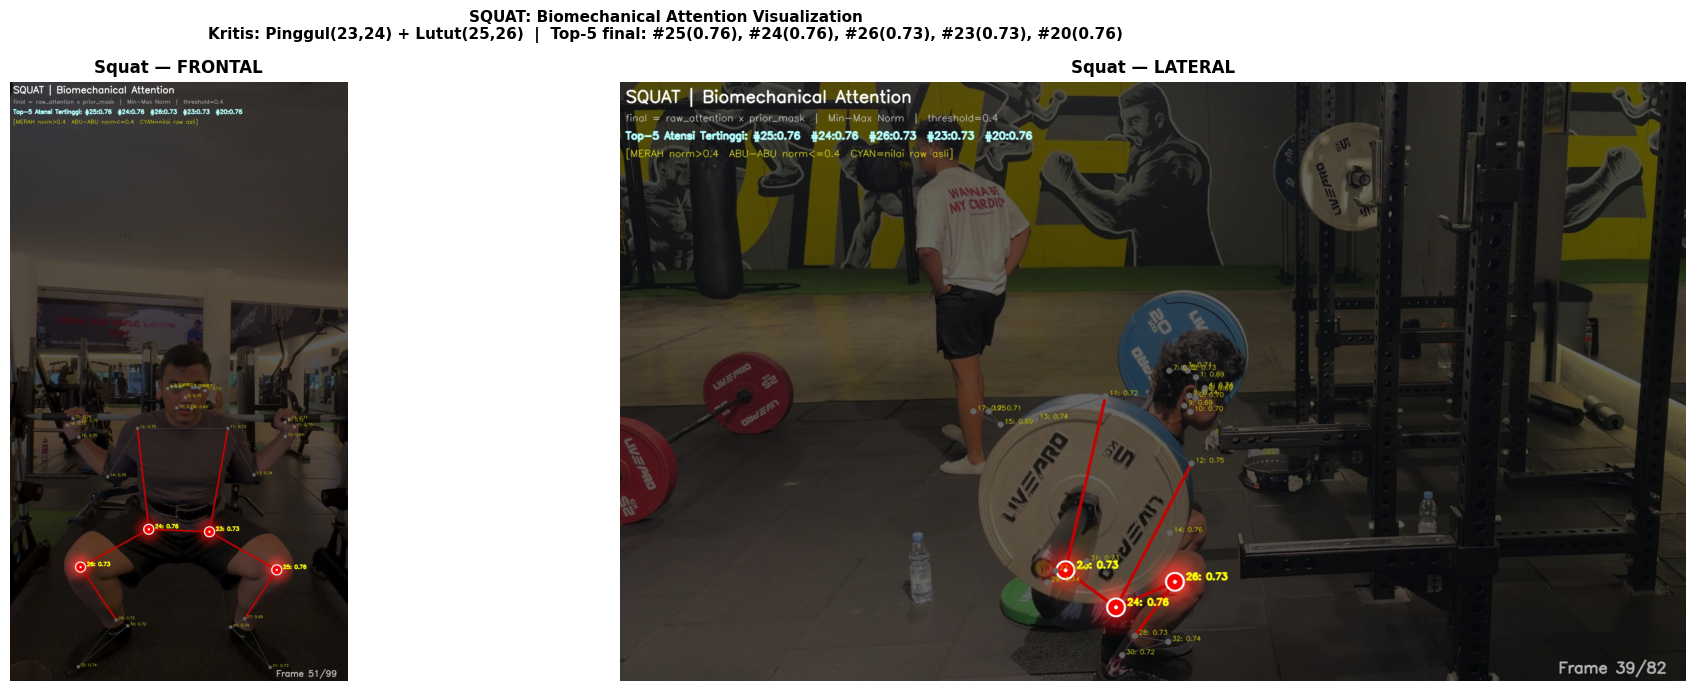

In [20]:

# ============================================================
# Eksekusi SQUAT
# Sendi kritis (1.0): Pinggul kiri/kanan (23, 24) + Lutut kiri/kanan (25, 26)
# Sendi lain   (0.1): 29 landmark sisanya
# ============================================================

squat_prior_mask = np.full(33, 0.1, dtype=np.float32)
for idx in [23, 24, 25, 26]:   # Pinggul (L/R) + Lutut (L/R)
    squat_prior_mask[idx] = 1.0

print("SQUAT — Exercise-Specific Spatial Prior Mask:")
print(f"  Sendi kritis (1.0) : Pinggul (23, 24) & Lutut (25, 26)")
print(f"  Sendi dasar  (0.1) : sisa 29 landmark")
print(f"  Efek: final_attention(kritis) = raw × 1.0  |  final_attention(lain) = raw × 0.1\n")

RAW_SQUAT_DIR = Path("../data/raw/Squat")
OUTPUT_DIR    = Path("../data/processed")


def _cari_video(folder: Path, keyword: str) -> "Path | None":
    """Cari .mp4 dengan keyword di nama file; prioritaskan file 'primer'."""
    candidates = sorted(folder.glob(f"*{keyword}*.mp4"))
    primer     = [p for p in candidates if "primer" in p.name]
    sekunder   = [p for p in candidates if "primer" not in p.name]
    ordered    = primer + sekunder
    return ordered[0] if ordered else None


squat_videos = {
    "frontal": _cari_video(RAW_SQUAT_DIR, "frontal"),
    "lateral": _cari_video(RAW_SQUAT_DIR, "lateral"),
}

print("Pencarian video Squat:")
for view, vpath in squat_videos.items():
    status = f"[OK]   {vpath.name}" if vpath else "[SKIP] tidak ditemukan"
    print(f"  {view.upper():8s}: {status}")

# ── Eksekusi Visualisasi ───────────────────────────────────────────────────────
squat_images = {}
for view, vpath in squat_videos.items():
    if vpath is None:
        print(f"\n[SKIP] Video Squat '{view}' tidak ditemukan di {RAW_SQUAT_DIR}")
        continue
    print(f"\n{'='*62}\nSquat {view.upper()} — {vpath.name}\n{'='*62}")
    out_video = OUTPUT_DIR / f"attention_squat_{view}.mp4"
    img_path  = render_biomechanical_attention(
        video_path          = str(vpath),
        output_path         = str(out_video),
        raw_attention       = raw_attention,
        exercise_prior_mask = squat_prior_mask,
    )
    if img_path:
        squat_images[view] = img_path

# ── Tampilkan Hasil ────────────────────────────────────────────────────────────
if squat_images:
    n    = len(squat_images)
    fig, axes = plt.subplots(1, n, figsize=(11 * n, 7))
    if n == 1:
        axes = [axes]
    for ax, (view, img_path) in zip(axes, squat_images.items()):
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(f"Squat — {view.upper()}", fontsize=12, fontweight="bold")
        ax.axis("off")
    top5 = ", ".join(
        f"#{int(i)}({raw_attention[i]:.2f})"
        for i in np.argsort(raw_attention * squat_prior_mask)[::-1][:5]
    )
    fig.suptitle(
        "SQUAT: Biomechanical Attention Visualization\n"
        f"Kritis: Pinggul(23,24) + Lutut(25,26)  |  Top-5 final: {top5}",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()
else:
    print("\n[PERINGATAN] Tidak ada output dihasilkan untuk Squat.")
    print("Pastikan file .mp4 tersedia di:", RAW_SQUAT_DIR)


## 4. Eksekusi DEADLIFT

Prior mask: **Bahu (11, 12)**, **Pinggul (23, 24)**, dan **Lutut (25, 26)** = 1.0 — rantai posterior untuk spine alignment dan hip-hinge.
Sendi lainnya diberi nilai dasar **0.1**.


DEADLIFT — Exercise-Specific Spatial Prior Mask:
  Sendi kritis (1.0) : Bahu (11, 12), Pinggul (23, 24) & Lutut (25, 26)
  Sendi dasar  (0.1) : sisa 27 landmark
  Efek: spine alignment + hip-hinge mendominasi visualisasi

Pencarian video Deadlift:
  FRONTAL   : [SKIP] tidak ditemukan
  LATERAL   : [OK]   primer_deadlift_lateral_subjek01_rep1.mp4

[SKIP] Video Deadlift 'frontal' tidak ditemukan di ..\data\raw\Deadlift

Deadlift LATERAL — primer_deadlift_lateral_subjek01_rep1.mp4
  raw_attention (sigmoid BSP) : min=0.6802, max=0.7639
  final_attention (×mask)     : min=0.0680, max=0.7639
  normalized (Min-Max)        : min=0.0000, max=1.0000
  Video: primer_deadlift_lateral_subjek01_rep1.mp4  |  1080×1920px  |  30.0 FPS  |  221 frame
  Total frame diproses : 221
  [TERSIMPAN] Video    : attention_deadlift_lateral.mp4
  [TERSIMPAN] Gambar   : attention_deadlift_lateral.jpg


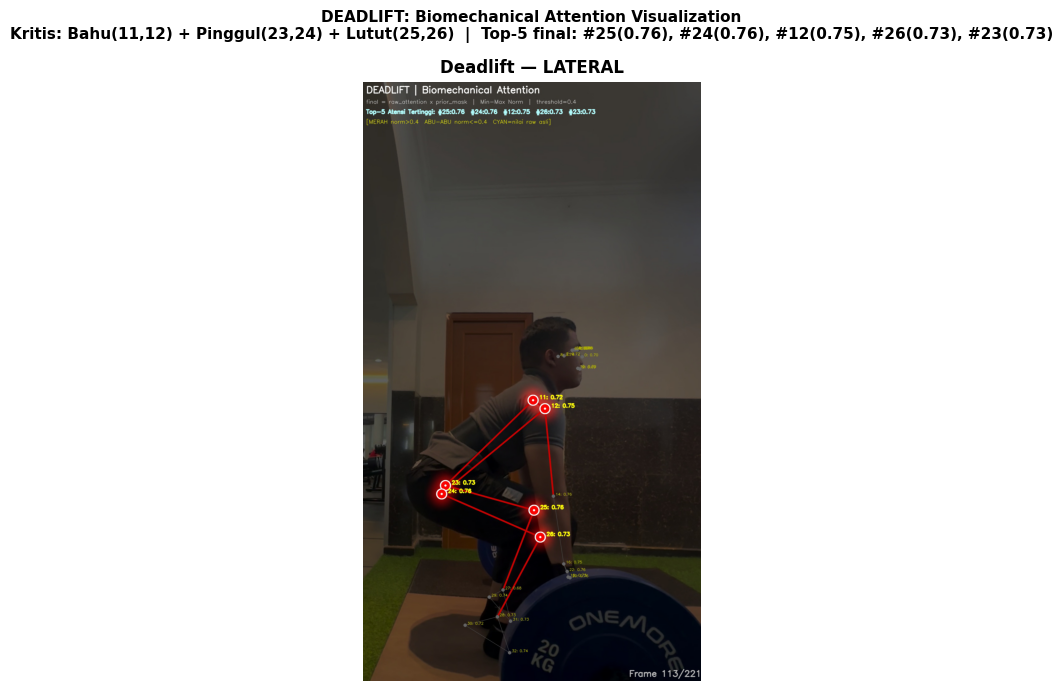

In [21]:

# ============================================================
# Eksekusi DEADLIFT
# Sendi kritis (1.0): Bahu (11, 12) + Pinggul (23, 24) + Lutut (25, 26)
# Sendi lain   (0.1): 27 landmark sisanya
# ============================================================

deadlift_prior_mask = np.full(33, 0.1, dtype=np.float32)
for idx in [11, 12, 23, 24, 25, 26]:   # Bahu (L/R) + Pinggul (L/R) + Lutut (L/R)
    deadlift_prior_mask[idx] = 1.0

print("DEADLIFT — Exercise-Specific Spatial Prior Mask:")
print(f"  Sendi kritis (1.0) : Bahu (11, 12), Pinggul (23, 24) & Lutut (25, 26)")
print(f"  Sendi dasar  (0.1) : sisa 27 landmark")
print(f"  Efek: spine alignment + hip-hinge mendominasi visualisasi\n")

RAW_DEADLIFT_DIR = Path("../data/raw/Deadlift")
OUTPUT_DIR       = Path("../data/processed")

deadlift_videos = {
    "frontal": _cari_video(RAW_DEADLIFT_DIR, "frontal"),
    "lateral": _cari_video(RAW_DEADLIFT_DIR, "lateral"),
}

# Fallback: ambil video apapun jika frontal/lateral tidak ditemukan
if all(v is None for v in deadlift_videos.values()):
    all_dl = sorted(RAW_DEADLIFT_DIR.glob("*.mp4"))
    for i, p in enumerate(all_dl[:2], start=1):
        deadlift_videos[f"video_{i:02d}"] = p

print("Pencarian video Deadlift:")
for view, vpath in deadlift_videos.items():
    status = f"[OK]   {vpath.name}" if vpath else "[SKIP] tidak ditemukan"
    print(f"  {view.upper():10s}: {status}")

# ── Eksekusi Visualisasi ───────────────────────────────────────────────────────
deadlift_images = {}
for view, vpath in deadlift_videos.items():
    if vpath is None:
        print(f"\n[SKIP] Video Deadlift '{view}' tidak ditemukan di {RAW_DEADLIFT_DIR}")
        continue
    print(f"\n{'='*62}\nDeadlift {view.upper()} — {vpath.name}\n{'='*62}")
    out_video = OUTPUT_DIR / f"attention_deadlift_{view}.mp4"
    img_path  = render_biomechanical_attention(
        video_path          = str(vpath),
        output_path         = str(out_video),
        raw_attention       = raw_attention,
        exercise_prior_mask = deadlift_prior_mask,
    )
    if img_path:
        deadlift_images[view] = img_path

# ── Tampilkan Hasil ────────────────────────────────────────────────────────────
if deadlift_images:
    n    = len(deadlift_images)
    fig, axes = plt.subplots(1, n, figsize=(11 * n, 7))
    if n == 1:
        axes = [axes]
    for ax, (view, img_path) in zip(axes, deadlift_images.items()):
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(f"Deadlift — {view.upper()}", fontsize=12, fontweight="bold")
        ax.axis("off")
    top5 = ", ".join(
        f"#{int(i)}({raw_attention[i]:.2f})"
        for i in np.argsort(raw_attention * deadlift_prior_mask)[::-1][:5]
    )
    fig.suptitle(
        "DEADLIFT: Biomechanical Attention Visualization\n"
        f"Kritis: Bahu(11,12) + Pinggul(23,24) + Lutut(25,26)  |  Top-5 final: {top5}",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()
else:
    print("\n[PERINGATAN] Tidak ada output dihasilkan untuk Deadlift.")
    print("Pastikan file .mp4 tersedia di:", RAW_DEADLIFT_DIR)


## 5. Eksekusi BENCH PRESS

Prior mask: **Bahu (11, 12)**, **Siku (13, 14)**, dan **Pergelangan Tangan (15, 16)** = 1.0 — rantai kinematik lengan untuk Elbow ROM.
Sendi lainnya diberi nilai dasar **0.1**.


BENCH PRESS — Exercise-Specific Spatial Prior Mask:
  Sendi kritis (1.0) : Bahu (11, 12), Siku (13, 14) & Pergelangan Tangan (15, 16)
  Sendi dasar  (0.1) : sisa 27 landmark
  Efek: rantai kinematik lengan (Elbow ROM) mendominasi visualisasi

Pencarian video Bench Press:
  FRONTAL   : [OK]   primer_benchpress_frontal_subjek01_rep1.mp4
  LATERAL   : [SKIP] tidak ditemukan

Bench Press FRONTAL — primer_benchpress_frontal_subjek01_rep1.mp4
  raw_attention (sigmoid BSP) : min=0.6802, max=0.7639
  final_attention (×mask)     : min=0.0680, max=0.7560
  normalized (Min-Max)        : min=0.0000, max=1.0000
  Video: primer_benchpress_frontal_subjek01_rep1.mp4  |  1080×1920px  |  30.0 FPS  |  94 frame
  Total frame diproses : 94
  [TERSIMPAN] Video    : attention_benchpress_frontal.mp4
  [TERSIMPAN] Gambar   : attention_benchpress_frontal.jpg

[SKIP] Video Bench Press 'lateral' tidak ditemukan di ..\data\raw\BenchPress


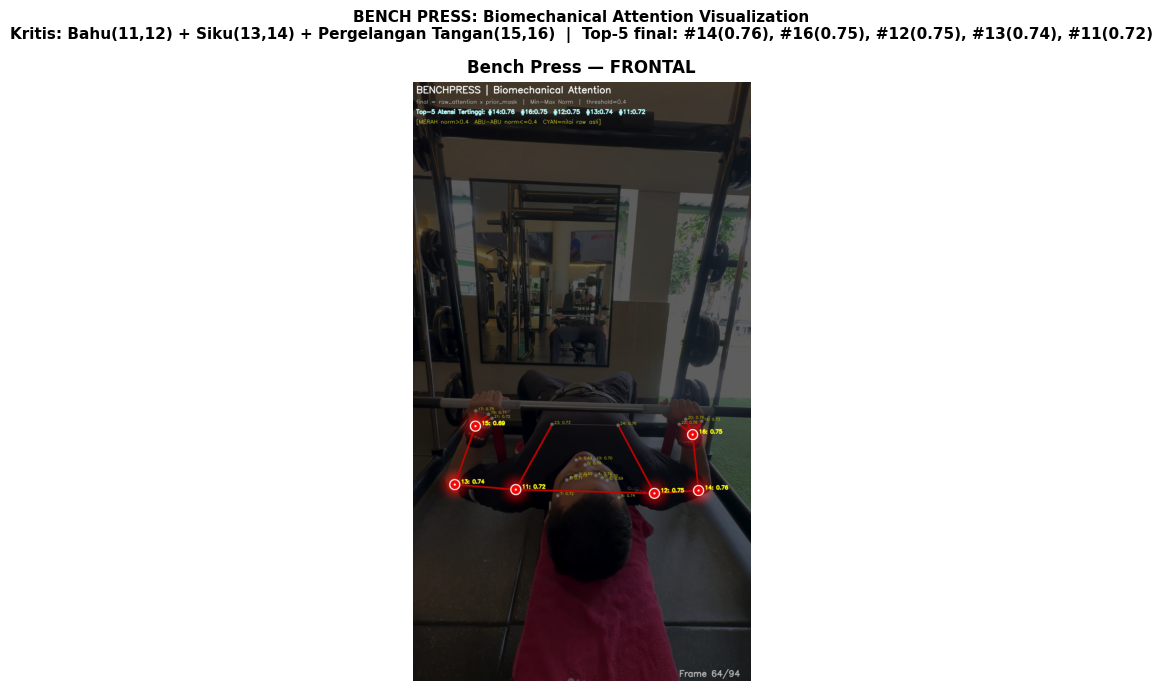

In [22]:

# ============================================================
# Eksekusi BENCH PRESS
# Sendi kritis (1.0): Bahu (11, 12) + Siku (13, 14) + Pergelangan Tangan (15, 16)
# Sendi lain   (0.1): 27 landmark sisanya
# ============================================================

benchpress_prior_mask = np.full(33, 0.1, dtype=np.float32)
for idx in [11, 12, 13, 14, 15, 16]:   # Bahu (L/R) + Siku (L/R) + Pergelangan Tangan (L/R)
    benchpress_prior_mask[idx] = 1.0

print("BENCH PRESS — Exercise-Specific Spatial Prior Mask:")
print(f"  Sendi kritis (1.0) : Bahu (11, 12), Siku (13, 14) & Pergelangan Tangan (15, 16)")
print(f"  Sendi dasar  (0.1) : sisa 27 landmark")
print(f"  Efek: rantai kinematik lengan (Elbow ROM) mendominasi visualisasi\n")

RAW_BENCH_DIR = Path("../data/raw/BenchPress")
OUTPUT_DIR    = Path("../data/processed")

bench_videos = {
    "frontal": _cari_video(RAW_BENCH_DIR, "frontal"),
    "lateral": _cari_video(RAW_BENCH_DIR, "lateral"),
}

# Fallback: ambil video apapun jika frontal/lateral tidak ditemukan
if all(v is None for v in bench_videos.values()):
    all_bp = sorted(RAW_BENCH_DIR.glob("*.mp4"))
    for i, p in enumerate(all_bp[:2], start=1):
        bench_videos[f"video_{i:02d}"] = p

print("Pencarian video Bench Press:")
for view, vpath in bench_videos.items():
    status = f"[OK]   {vpath.name}" if vpath else "[SKIP] tidak ditemukan"
    print(f"  {view.upper():10s}: {status}")

# ── Eksekusi Visualisasi ───────────────────────────────────────────────────────
bench_images = {}
for view, vpath in bench_videos.items():
    if vpath is None:
        print(f"\n[SKIP] Video Bench Press '{view}' tidak ditemukan di {RAW_BENCH_DIR}")
        continue
    print(f"\n{'='*62}\nBench Press {view.upper()} — {vpath.name}\n{'='*62}")
    out_video = OUTPUT_DIR / f"attention_benchpress_{view}.mp4"
    img_path  = render_biomechanical_attention(
        video_path          = str(vpath),
        output_path         = str(out_video),
        raw_attention       = raw_attention,
        exercise_prior_mask = benchpress_prior_mask,
    )
    if img_path:
        bench_images[view] = img_path

# ── Tampilkan Hasil ────────────────────────────────────────────────────────────
if bench_images:
    n    = len(bench_images)
    fig, axes = plt.subplots(1, n, figsize=(11 * n, 7))
    if n == 1:
        axes = [axes]
    for ax, (view, img_path) in zip(axes, bench_images.items()):
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(f"Bench Press — {view.upper()}", fontsize=12, fontweight="bold")
        ax.axis("off")
    top5 = ", ".join(
        f"#{int(i)}({raw_attention[i]:.2f})"
        for i in np.argsort(raw_attention * benchpress_prior_mask)[::-1][:5]
    )
    fig.suptitle(
        "BENCH PRESS: Biomechanical Attention Visualization\n"
        f"Kritis: Bahu(11,12) + Siku(13,14) + Pergelangan Tangan(15,16)  |  Top-5 final: {top5}",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()
else:
    print("\n[PERINGATAN] Tidak ada output dihasilkan untuk Bench Press.")
    print("Pastikan file .mp4 tersedia di:", RAW_BENCH_DIR)
